In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ======================================================
# ヘルパー関数
# ======================================================
def initialize_opinion_grid(n, num_opinions):
    """
    n x n のグリッドを用意し、
    各セル(エージェント)に長さ num_opinions の[0,1)一様乱数ベクトルをセットする。
    
    返り値の shape は (n, n, num_opinions) となる。
    """
    return np.random.rand(n, n, num_opinions)

def get_random_neighbor4(n, x, y):
    """
    上下左右4近傍からランダムに1つ返す。
    トーラス状（境界はつながっている）とする。
    """
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    dx, dy = random.choice(neighbors)
    nx = (x + dx) % n
    ny = (y + dy) % n
    return nx, ny

def average_opinion_difference(opinion1, opinion2):
    """
    2つの意見ベクトル (shape=(num_opinions,)) の
    「平均絶対差分」を返す。
    """
    diff_vec = np.abs(opinion1 - opinion2)
    return diff_vec.mean()

def step_opinion_one_pair(grid):
    """
    グリッド中のランダムに選ばれた1セルと、その4近傍（または全域ランダム）から1セル
    を取り出し、2者間だけ意見を更新する。
    
    grid: shape = (N, N, num_opinions)
    """
    n = grid.shape[0]
    
    # ランダムに1セル(=1エージェント)を選ぶ
    x = random.randint(0, n - 1)
    y = random.randint(0, n - 1)
    
    # 相手セル(=もう1エージェント)を選ぶ
    if spatial_interactions:
        nx, ny = get_random_neighbor4(n, x, y)
    else:
        nx = random.randint(0, n - 1)
        ny = random.randint(0, n - 1)

    # 2つのエージェントの意見ベクトルを取得
    agent1 = grid[x, y].copy()  # shape = (num_opinions,)
    agent2 = grid[nx, ny].copy()

    # 平均絶対差分を計算
    diff = average_opinion_difference(agent1, agent2)

    # --- 正の影響 (意見差が閾値以内 => 引き寄せ) ---
    if diff < confidence_threshold:
        # 各次元で収束方向に更新
        new1 = agent1 + learning_rate * (agent2 - agent1)
        new2 = agent2 + learning_rate * (agent1 - agent2)
        grid[x, y] = new1
        grid[nx, ny] = new2

    # --- 負の影響 (反目) ---
    elif repulsion and diff > confidence_threshold:
        # ここでは、2者の「平均値」がどちらが大きいかで分岐して、
        # すべての次元をその方向にずらす、という例にする。
        # (あるいは次元ごとに if agent1[i] > agent2[i] ... としてもOK。)
        mean1 = agent1.mean()
        mean2 = agent2.mean()
        
        if mean1 > mean2:
            # agent1 側が平均的に大きい
            # 各次元で反発計算
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 - agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 + agent2) * 0.5
            new1 = np.clip(new1, 0.0, 1.0)
            new2 = np.clip(new2, 0.0, 1.0)
        else:
            # agent2 側が平均的に大きい
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 + agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 - agent2) * 0.5
            new1 = np.clip(new1, 0.0, 1.0)
            new2 = np.clip(new2, 0.0, 1.0)
        
        grid[x, y]   = new1
        grid[nx, ny] = new2

    # それ以外の場合は何もしない (diff == threshold とか、repulsion=Falseの場合など)
    return

def run_simulation(N, num_opinions, num_steps=10000):
    """
    num_opinions 個の意見ベクトルを持つ N×Nエージェントでシミュレーションを実行し、
    最終的な状態の grid を返す。
    """
    # グリッドを初期化 (shape: (N, N, num_opinions))
    grid = initialize_opinion_grid(N, num_opinions)
    
    for _ in range(num_steps):
        step_opinion_one_pair(grid)
    
    return grid

def compute_polarization(grid):
    """
    grid (shape=(N, N, num_opinions)) の全エージェントペアについて
    「平均絶対差分」を計算し、それらの分散 (Var) を返す。
    """
    # エージェント数 M
    N = grid.shape[0]
    M = N * N
    
    # 各ペアの平均絶対差分 D_ij を集める
    opinions = grid.reshape(M, -1)  # shape=(M, num_opinions)
    diffs = []
    for i in range(M):
        for j in range(i+1, M):
            d = average_opinion_difference(opinions[i], opinions[j])
            diffs.append(d)
    diffs = np.array(diffs)
    return diffs.var()

def compute_extremism(grid):
    """
    grid (shape=(N, N, num_opinions)) について、
    各エージェントの意見ベクトルの平均値が 0.9 以上となる割合を返す。
    """
    N = grid.shape[0]
    M = N * N
    opinions = grid.reshape(M, -1)  # shape=(M, num_opinions)
    # 各エージェントの平均値
    means = opinions.mean(axis=1)
    # 0.9以上となる数
    count_extreme = np.sum(means >= 0.9)
    return count_extreme / M







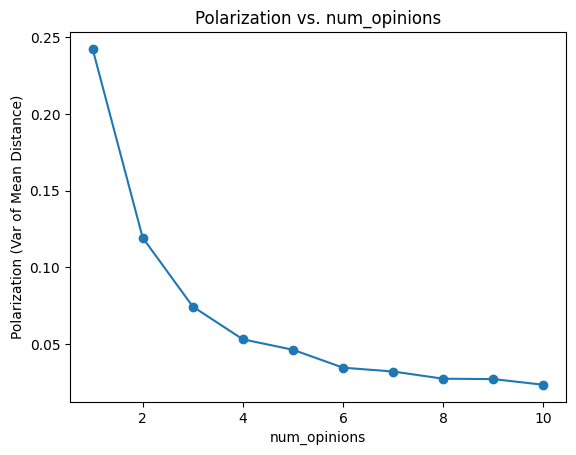

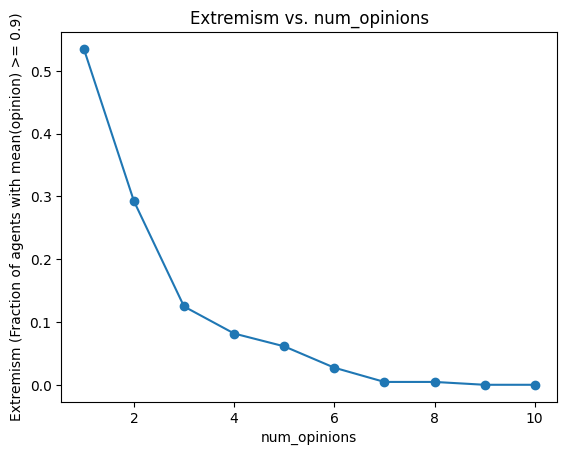

In [9]:

# ======================================================
# パラメータ設定
# ======================================================
N = 21                      # グリッドの一辺の長さ (エージェント数は N*N)
num_steps = 10000           # シミュレーション総ステップ数
store_interval = 100        # スナップショットを保存する間隔(今回の分析では使わない)
confidence_threshold = 0.3  # 引き寄せ・反発の閾値
learning_rate = 0.5         # 学習率
repulsion = True            # 反発を導入するか
spatial_interactions = True # 近傍のみ (True) or 全域ランダム (False)

# ======================================================
# num_opinions を 1 から 10 まで変化させたときの
# Polarization と Extremism を調べ、グラフ描画
# ======================================================

polarization_list = []
extremism_list = []
opinions_range = range(1, 11)
for k in opinions_range:
    # シミュレーション実行
    final_grid = run_simulation(N, num_opinions=k, num_steps=num_steps)
    
    # Polarization を計算
    pol = compute_polarization(final_grid)
    # Extremism を計算
    ext = compute_extremism(final_grid)
    
    polarization_list.append(pol)
    extremism_list.append(ext)

# グラフ描画 (Polarization)
plt.figure()
plt.plot(list(opinions_range), polarization_list, marker='o')
plt.title("Polarization vs. num_opinions")
plt.xlabel("num_opinions")
plt.ylabel("Polarization (Var of Mean Distance)")

# グラフ描画 (Extremism)
plt.figure()
plt.plot(list(opinions_range), extremism_list, marker='o')
plt.title("Extremism vs. num_opinions")
plt.xlabel("num_opinions")
plt.ylabel("Extremism (Fraction of agents with mean(opinion) >= 0.9)")

plt.show()

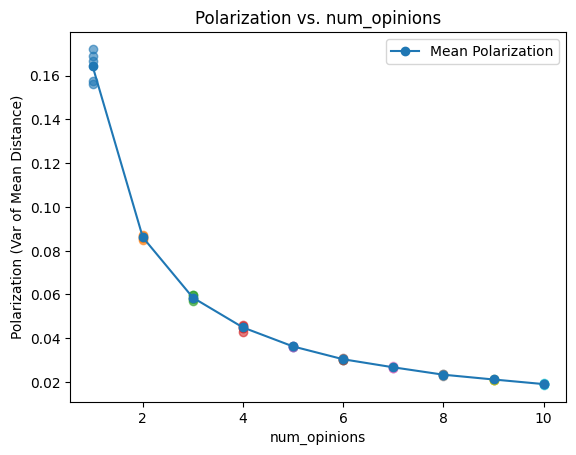

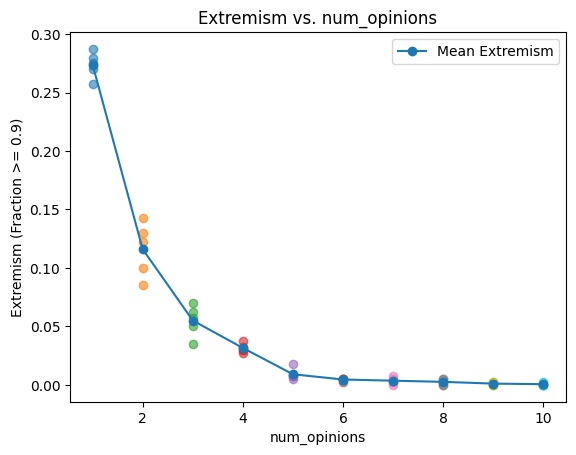

In [8]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ======================================================
# パラメータ設定 (適宜変更してください)
# ======================================================
N = 20                      # グリッドの一辺の長さ
num_steps = 2000           # シミュレーション総ステップ数
confidence_threshold = 0.2
learning_rate = 0.5
repulsion = True
spatial_interactions = True

# シミュレーションを何度繰り返すか
n_experiments = 5

# こちらの range で num_opinions を変化
opinions_range = range(1, 11)


# ======================================================
# 必要な関数 (多次元意見モデルの例)
# ======================================================
def initialize_opinion_grid(n, num_opinions):
    return np.random.rand(n, n, num_opinions)

def get_random_neighbor4(n, x, y):
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    dx, dy = random.choice(neighbors)
    nx = (x + dx) % n
    ny = (y + dy) % n
    return nx, ny

def average_opinion_difference(opinion1, opinion2):
    diff_vec = np.abs(opinion1 - opinion2)
    return diff_vec.mean()

def step_opinion_one_pair(grid):
    n = grid.shape[0]
    # ランダムに1セルを選ぶ
    x = random.randint(0, n - 1)
    y = random.randint(0, n - 1)
    # 相手セル
    if spatial_interactions:
        nx, ny = get_random_neighbor4(n, x, y)
    else:
        nx = random.randint(0, n - 1)
        ny = random.randint(0, n - 1)

    agent1 = grid[x, y].copy()
    agent2 = grid[nx, ny].copy()

    diff = average_opinion_difference(agent1, agent2)

    # 引き寄せ
    if diff < confidence_threshold:
        new1 = agent1 + learning_rate * (agent2 - agent1)
        new2 = agent2 + learning_rate * (agent1 - agent2)
        grid[x, y]   = new1
        grid[nx, ny] = new2

    # 反発
    elif repulsion and diff > confidence_threshold:
        mean1 = agent1.mean()
        mean2 = agent2.mean()
        
        if mean1 > mean2:
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 - agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 + agent2) * 0.5
        else:
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 + agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 - agent2) * 0.5
        
        # 値が爆発しないよう、クリップする等の対処を入れておくと安全
        new1 = np.clip(new1, 0.0, 1.0)
        new2 = np.clip(new2, 0.0, 1.0)

        grid[x, y]   = new1
        grid[nx, ny] = new2

def run_simulation(N, num_opinions, num_steps=10000):
    grid = initialize_opinion_grid(N, num_opinions)
    for _ in range(num_steps):
        step_opinion_one_pair(grid)
    return grid

def compute_polarization(grid):
    N = grid.shape[0]
    M = N*N
    opinions = grid.reshape(M, -1)
    diffs = []
    for i in range(M):
        for j in range(i+1, M):
            d = average_opinion_difference(opinions[i], opinions[j])
            diffs.append(d)
    diffs = np.array(diffs)
    return diffs.var()

def compute_extremism(grid):
    N = grid.shape[0]
    M = N*N
    opinions = grid.reshape(M, -1)
    means = opinions.mean(axis=1)
    count_extreme = np.sum(means >= 0.9)
    return count_extreme / M


# ======================================================
# シミュレーションの繰り返し + グラフ描画
# ======================================================
all_polarization_means = []
all_extremism_means = []

# 各 num_opinions の結果を格納するための
# 「個々の試行結果一覧」(プロット用)も用意
all_polarization_raw = []
all_extremism_raw = []

for k in opinions_range:
    pol_list = []
    ext_list = []
    # n_experiments 回まわす
    for _ in range(n_experiments):
        final_grid = run_simulation(N, num_opinions=k, num_steps=num_steps)
        pol_list.append(compute_polarization(final_grid))
        ext_list.append(compute_extremism(final_grid))
    
    # 平均値を記録
    pol_mean = np.mean(pol_list)
    ext_mean = np.mean(ext_list)
    all_polarization_means.append(pol_mean)
    all_extremism_means.append(ext_mean)

    # 個々の試行結果 (ドットで重ねる用)
    all_polarization_raw.append(pol_list)
    all_extremism_raw.append(ext_list)


# --------
# Polarization の描画
# --------
plt.figure()
# まず平均を折れ線グラフとしてプロット
plt.plot(
    opinions_range,
    all_polarization_means,
    marker='o',
    label='Mean Polarization'
)
# 次に同じ x 軸の位置に、各試行の値をドットで重ねる
#   x 座標は k, y 座標は pol_list 中の各要素
for i, k in enumerate(opinions_range):
    pol_list = all_polarization_raw[i]
    # x 座標を「k」で固定し、y は pol_list の各値
    # 同じ k の位置に散布 (少し横方向にずらしたい場合は +α してもよい)
    plt.scatter([k]*len(pol_list), pol_list, alpha=0.6)

plt.title("Polarization vs. num_opinions")
plt.xlabel("num_opinions")
plt.ylabel("Polarization (Var of Mean Distance)")
plt.legend()


# --------
# Extremism の描画
# --------
plt.figure()
# 平均を折れ線グラフ
plt.plot(
    opinions_range,
    all_extremism_means,
    marker='o',
    label='Mean Extremism'
)
# 個別値をドットで散布
for i, k in enumerate(opinions_range):
    ext_list = all_extremism_raw[i]
    plt.scatter([k]*len(ext_list), ext_list, alpha=0.6)

plt.title("Extremism vs. num_opinions")
plt.xlabel("num_opinions")
plt.ylabel("Extremism (Fraction >= 0.9)")
plt.legend()

plt.show()


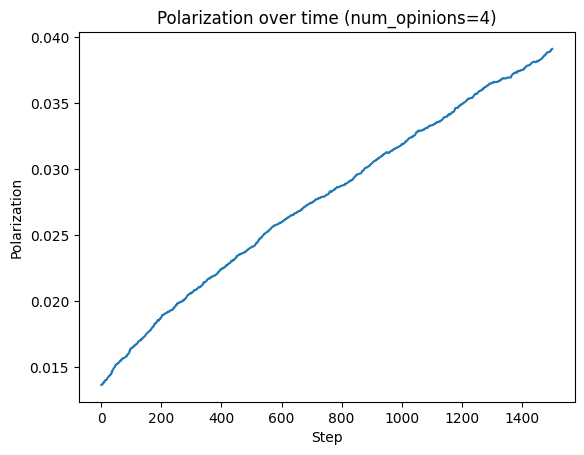

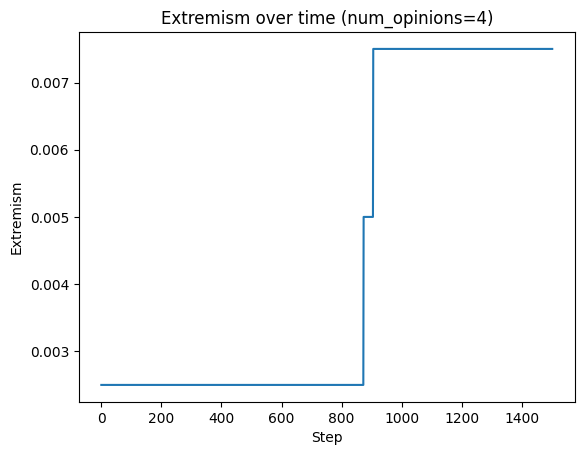

In [18]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- パラメータ設定 ---
N = 20                       # グリッドの一辺の長さ
num_opinions = 4            # 意見ベクトルの次元数
num_steps = 1500          # 観測ステップ数
confidence_threshold = 0.2  # 近づく/反発の閾値
learning_rate = 0.5
repulsion = True
spatial_interactions = True

# ======================================================
# 必要な関数
# ======================================================
def initialize_opinion_grid(n, num_opinions):
    """
    n x n のグリッドを用意し、
    各セル(エージェント)に長さ num_opinions の[0,1)一様乱数ベクトルをセットする。
    """
    return np.random.rand(n, n, num_opinions)

def get_random_neighbor4(n, x, y):
    """
    上下左右4近傍からランダムに1つ返す (トーラス状)。
    """
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    dx, dy = random.choice(neighbors)
    nx = (x + dx) % n
    ny = (y + dy) % n
    return nx, ny

def average_opinion_difference(opinion1, opinion2):
    """
    2つの意見ベクトル (shape=(num_opinions,)) の
    各成分絶対差の平均を返す。
    """
    diff_vec = np.abs(opinion1 - opinion2)
    return diff_vec.mean()

def step_opinion_one_pair(grid):
    """
    ランダムに選ばれた1セルと、さらにもう1セル(近傍 or 全域ランダム)のペアを更新する。
    """
    n = grid.shape[0]
    
    # ランダムに1セル
    x = random.randint(0, n - 1)
    y = random.randint(0, n - 1)
    
    # ペアとなる相手を選ぶ
    if spatial_interactions:
        nx, ny = get_random_neighbor4(n, x, y)
    else:
        nx = random.randint(0, n - 1)
        ny = random.randint(0, n - 1)

    agent1 = grid[x, y].copy()
    agent2 = grid[nx, ny].copy()

    diff = average_opinion_difference(agent1, agent2)

    # --- 近づく (引き寄せ) ---
    if diff < confidence_threshold:
        new1 = agent1 + learning_rate * (agent2 - agent1)
        new2 = agent2 + learning_rate * (agent1 - agent2)
        grid[x, y]   = new1
        grid[nx, ny] = new2
    
    # --- 反発 ---
    elif repulsion and diff > confidence_threshold:
        mean1 = agent1.mean()
        mean2 = agent2.mean()
        
        if mean1 > mean2:
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 - agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 + agent2) * 0.5
        else:
            new1 = agent1 + learning_rate * (agent1 - agent2) * (1 + agent1) * 0.5
            new2 = agent2 + learning_rate * (agent2 - agent1) * (1 - agent2) * 0.5

        # 値が爆発しないようにクリップ（任意）
        new1 = np.clip(new1, 0.0, 1.0)
        new2 = np.clip(new2, 0.0, 1.0)

        grid[x, y]   = new1
        grid[nx, ny] = new2

def compute_polarization(grid):
    """
    グリッド (N, N, num_opinions) の全エージェントペアについて
    平均絶対差を計算し、その分散を返す。
    """
    N = grid.shape[0]
    M = N*N
    opinions = grid.reshape(M, -1)
    diffs = []
    for i in range(M):
        for j in range(i+1, M):
            d = average_opinion_difference(opinions[i], opinions[j])
            diffs.append(d)
    diffs = np.array(diffs)
    return diffs.var()

def compute_extremism(grid):
    """
    グリッド中の各エージェントの意見ベクトル平均値が 0.9 以上の割合を計算。
    """
    N = grid.shape[0]
    M = N*N
    opinions = grid.reshape(M, -1)
    means = opinions.mean(axis=1)
    count_extreme = np.sum(means >= 0.9)
    return count_extreme / M

# ======================================================
# メイン処理:
#   1. グリッド初期化
#   2. stepごとに1ペア更新 & polar/extrem計算
#   3. グラフ描画
# ======================================================
# グリッド初期化
grid = initialize_opinion_grid(N, num_opinions)

# 記録用リスト
pol_history = []
ext_history = []

for step in range(1, num_steps+1):
    # ランダムに1ペア更新
    step_opinion_one_pair(grid)
    
    # Polarization と Extremism を計算・記録
    pol = compute_polarization(grid)
    ext = compute_extremism(grid)
    pol_history.append(pol)
    ext_history.append(ext)

# --------------------
# グラフ描画
# --------------------
# Polarization の変化
plt.figure()
plt.plot(range(1, num_steps+1), pol_history)
plt.title("Polarization over time (num_opinions=4)")
plt.xlabel("Step")
plt.ylabel("Polarization")

# Extremism の変化
plt.figure()
plt.plot(range(1, num_steps+1), ext_history)
plt.title("Extremism over time (num_opinions=4)")
plt.xlabel("Step")
plt.ylabel("Extremism")

plt.show()
